# **Elasticidade-Preço com Double Machine Learning**

Em muitos mercados o preço não é fixo, pois reage à demanda de maneira dinâmica. Plataformas de e-commerce, aplicativos de transporte e hotéis sobem o preço à medida que a procura aumenta. Isso gera um problema pois nos períodos de alta demanda observamos, ao mesmo tempo, preços mais altos e volumes de venda mais altos. Logo, a correlação entre preço e quantidade vendida se torna espúria, e uma regressão ingênua pode concluir que a demanda é pouco sensível ao preço, ou ainda que preço maior vende mais.

Este notebook simula um painel de vendas diárias sob o contexto de preço dinâmico, com elasticidade conhecida, e mostra como o **Double Machine Learning (DML)** captura o efeito do preço sobre a demanda, enquanto um modelo de regressão _log-log_ o subestima, o que na prática implicaria em erro de precificação e perda financeira.

## **Preparação do Notebook**

In [1]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import holidays
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from highlight_text import fig_text

import statsmodels.api as sm
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from doubleml import DoubleMLData, DoubleMLPLR

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "figure.dpi": 250,
    }
)

# paleta
preto = "#222222"
vermelho = "#c0392b"
cinza = "#9aa3a8"
cinza_claro = "#e3e7e9"

seed = 42
rng = np.random.default_rng(seed)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

In [2]:
# funções auxiliares para visualização
def limpar(ax):
    for lado in ax.spines.values():
        lado.set_visible(False)
    ax.tick_params(length=0)


def titulo(fig, texto, sub, x=0.09, y=0.98, size=19):
    fig_text(
        x=x,
        y=y,
        s=f"{texto}\n<{sub}>",
        fig=fig,
        fontsize=size,
        fontweight="bold",
        color=preto,
        ha="left",
        va="top",
        highlight_textprops=[{"fontsize": 11, "fontweight": "normal", "color": cinza}],
    )


def fonte(fig, texto, x=0.09, y=0.03, size=8):
    fig_text(
        x=x,
        y=y,
        s=texto,
        fig=fig,
        fontsize=size,
        color=cinza,
        ha="left",
        va="top",
        highlight_textprops=[{"fontweight": "bold", "color": preto}] * texto.count("<"),
    )

## **Construção dos Dados Sintéticos**
A elasticidade-preço mede a variação percentual da quantidade vendida diante de uma variação de 1% no preço. Em um modelo **log-log** ela é exatamente a inclinação:

$$
\log Q_{it} = \alpha_i + \beta_i \log P_{it} + g(X_{it}) + \varepsilon_{it}
$$

onde $Q_{it}$ é a quantidade da SKU $i$ no dia $t$, $P_{it}$ o preço, $X_{it}$ os controles sazonais e demanda, e $\beta_i$ a elasticidade. Como os dados são simulados, o $\beta_i$ verdadeiro é conhecido e serve de para comparação do resultado obtido com o modelo usado.

O principal ponto da simulação é o confundimento do efeito de demanda sob o preço, como por exemplo em contextos de precificação dinâmica que o preço sobe em resposta a altos volumes de demanda. Existe uma demanda mais forte perto de feriados e alta estação que aumentam ao mesmo tempo a quantidade vendida e o preço que acompanha a procura. Esse movimentação simultânea mascara a relação negativa real entre preço e quantidade.

In [3]:
def construir_calendario(datas, feriados):
    """Componentes de calendário compartilhados por todas as SKUs."""
    cal = pd.DataFrame({"data": datas})
    cal["fim_de_semana"] = (cal["data"].dt.dayofweek >= 5).astype(int)
    cal["feriado"] = cal["data"].dt.date.isin(feriados).astype(int)
    cal["sazonal"] = np.sin(2 * np.pi * cal["data"].dt.dayofyear / 365.25)
    return cal


def simular_sku(cal, sku, preco_base, demanda_base, elasticidade, rng):
    """Gera preço e quantidade diários sob precificação dinâmica (preço segue a demanda)."""
    n = len(cal)
    d = cal.copy()
    d["sku"] = sku
    d["elasticidade"] = elasticidade

    # demanda aumenta perto de feriados e alta estação
    d["demanda_latente"] = (
        0.6 * d["sazonal"] + 0.5 * d["feriado"] + rng.normal(0, 0.10, n)
    )

    # o preço sobe quando a demanda aumenta
    log_preco = (
        np.log(preco_base)
        + 0.30 * d["demanda_latente"]
        + 0.08 * d["fim_de_semana"]
        + rng.normal(0, 0.14, n)
    )
    d["preco"] = np.exp(log_preco).round(2)
    d["log_preco"] = np.log(d["preco"])

    # quantidade = elasticidade real + demanda + calendário
    log_qtd = (
        np.log(demanda_base)
        + elasticidade * d["log_preco"]
        + 0.85 * d["demanda_latente"]
        + 0.15 * d["sazonal"]
        - 0.10 * d["fim_de_semana"]
        + rng.normal(0, 0.10, n)
    )
    d["quantidade"] = np.exp(log_qtd).round().clip(1).astype(int)
    d["log_qtd"] = np.log(d["quantidade"])
    d["receita"] = (d["preco"] * d["quantidade"]).round(2)
    return d


# itens simulados
skus = {
    "SKU01": {"preco_base": 18.5, "demanda_base": 240, "elasticidade": -1.5},
    "SKU02": {"preco_base": 5.8, "demanda_base": 520, "elasticidade": -2.2},
    "SKU03": {"preco_base": 14.0, "demanda_base": 180, "elasticidade": -1.6},
    "SKU04": {"preco_base": 4.5, "demanda_base": 410, "elasticidade": -1.8},
}

datas = pd.date_range("2023-01-01", "2025-12-31", freq="D")
feriados = holidays.country_holidays("BR", years=range(2023, 2026), language="pt_BR")
calendario = construir_calendario(datas, feriados)

df = pd.concat(
    [simular_sku(calendario, s, **p, rng=rng) for s, p in skus.items()],
    ignore_index=True,
)
df.head()

,data,fim_de_semana,feriado,sazonal,sku,elasticidade,demanda_latente,preco,log_preco,quantidade,log_qtd,receita
0,2023-01-01,1,1,0.017,SKU01,-1.500,0.541,29.400,3.381,2,0.693,58.800
1,2023-01-02,0,0,0.034,SKU01,-1.500,-0.083,19.340,2.962,3,1.099,58.020
2,2023-01-03,0,0,0.052,SKU01,-1.500,0.106,21.890,3.086,3,1.099,65.670
3,2023-01-04,0,0,0.069,SKU01,-1.500,0.135,22.930,3.132,2,0.693,45.860
4,2023-01-05,0,0,0.086,SKU01,-1.500,-0.144,20.760,3.033,2,0.693,41.520


## **Análise Exploratória**

Antes de modelar, vale conferir o efeito da precificação dinâmica nos dados. Duas leituras bastam: como preço e demanda se movem ao longo do tempo, e qual é a relação *aparente* entre os dois — aquela que uma regressão ingênua enxergaria.

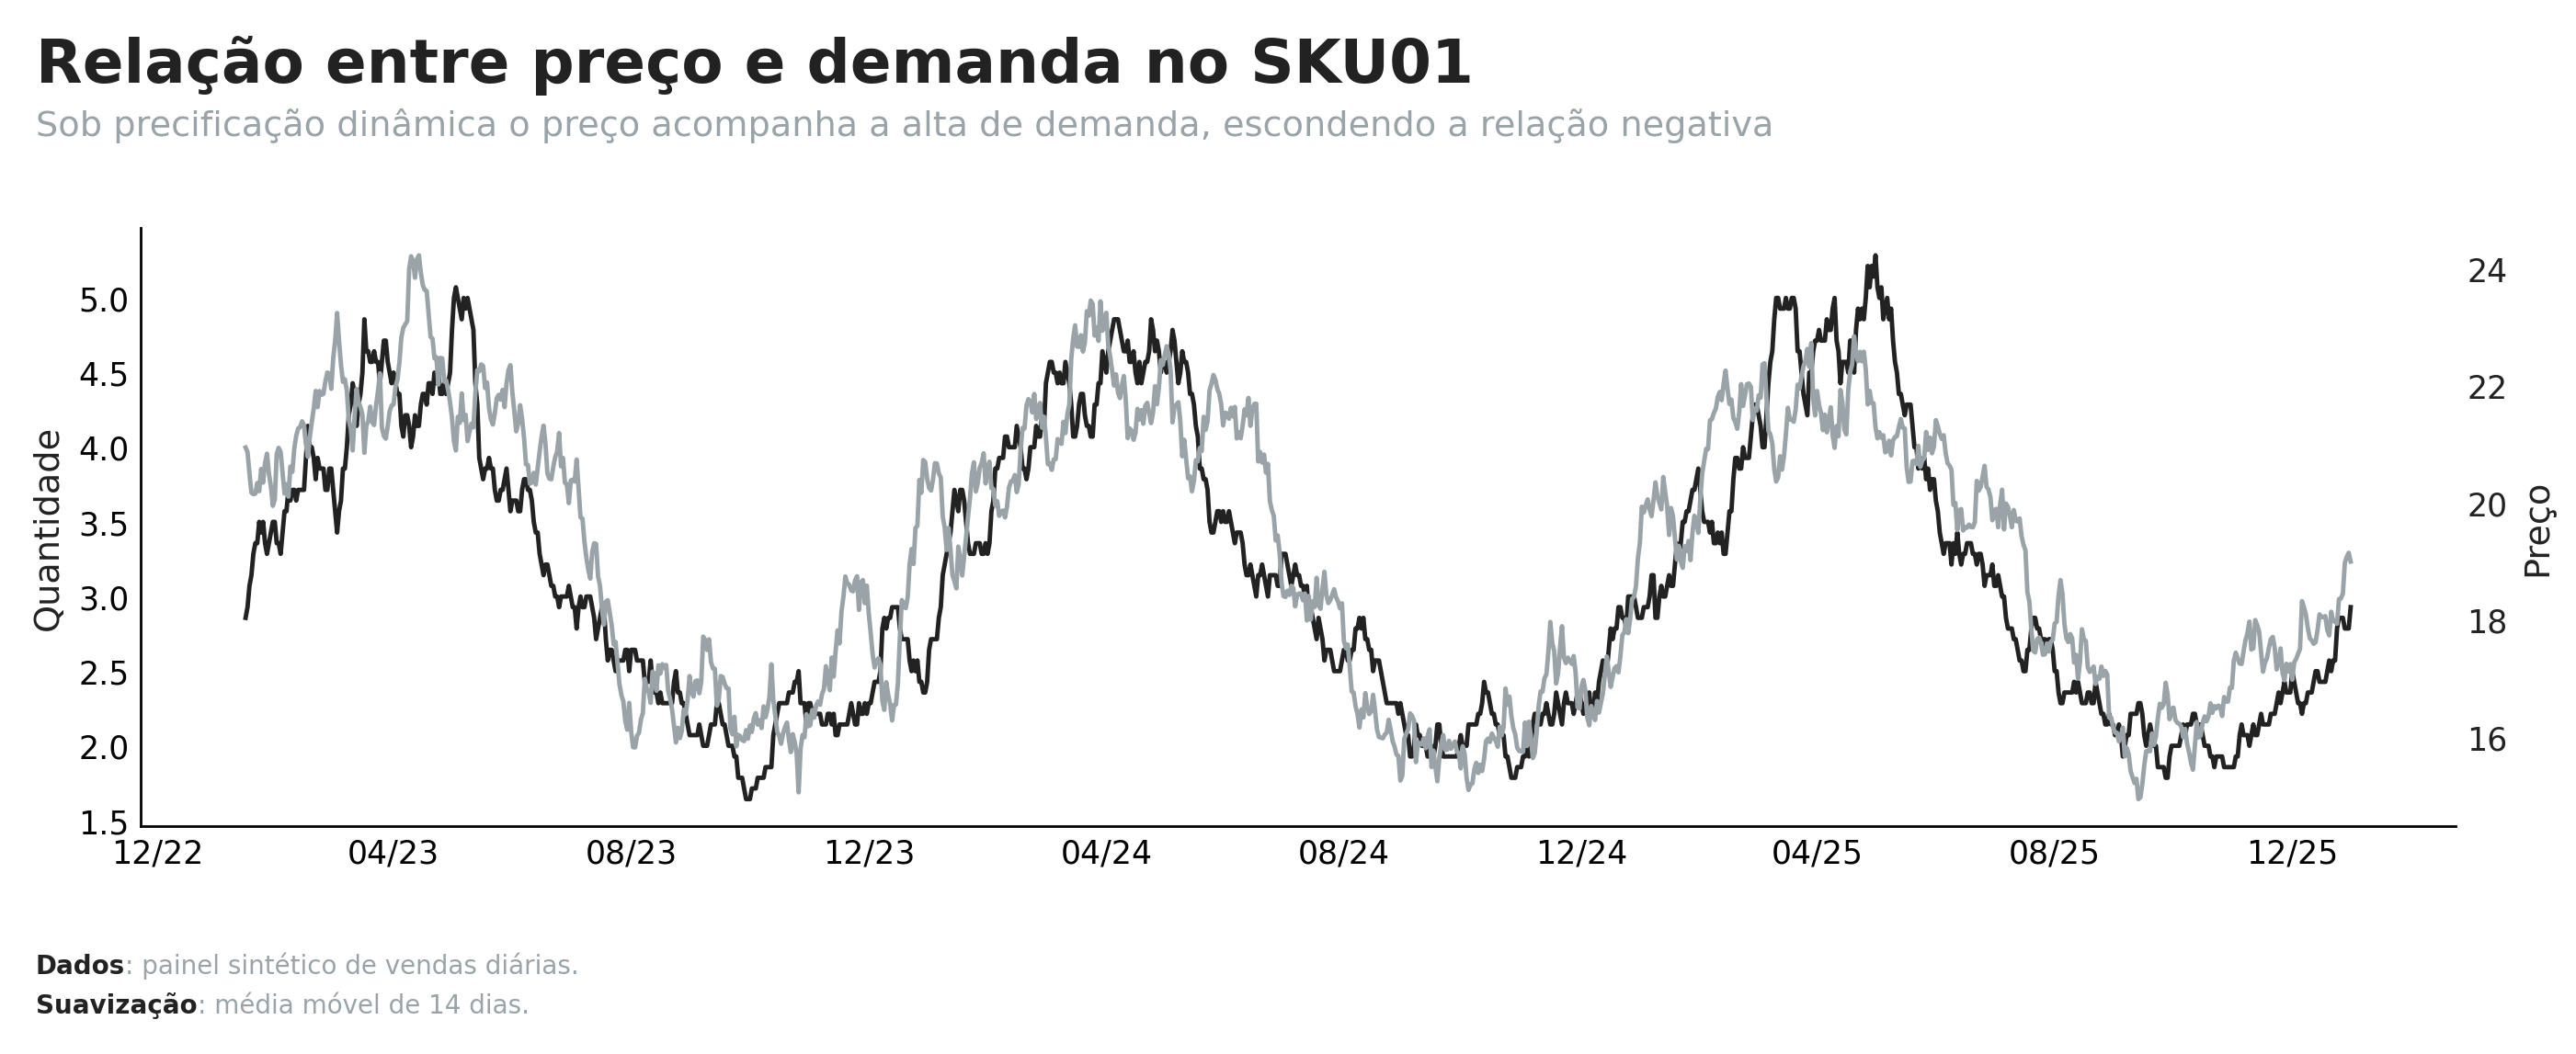

In [4]:
# fig 1: série temporal simultânea de preço e demanda com eixos compartilhados
sku_ex = "SKU01"
serie = (
    df.loc[df["sku"] == sku_ex]
    .set_index("data")[["preco", "quantidade"]]
    .rolling(14, min_periods=1)
    .mean()
)[14:]

fig, ax = plt.subplots(figsize=(13, 4.2))
fig.subplots_adjust(top=0.78, bottom=0.16)

ax.plot(serie.index, serie["quantidade"], color=preto, linewidth=1.4, label="Quantidade")
ax.set_ylabel("Quantidade", color=preto)
limpar(ax)

ax2 = ax.twinx()
ax2.plot(serie.index, serie["preco"], color=cinza, linewidth=1.4, label="Preço")
ax2.set_ylabel("Preço", color=preto)
ax2.spines["top"].set_visible(False)
ax2.tick_params(length=0, colors=preto)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%y"))

titulo(
    fig,
    f"Relação entre preço e demanda no {sku_ex}",
    "Sob precificação dinâmica o preço acompanha a alta de demanda, escondendo a relação negativa",
)
fonte(
    fig,
    "<Dados>: painel sintético de vendas diárias.\n<Suavização>: média móvel de 14 dias.",
)
plt.show()

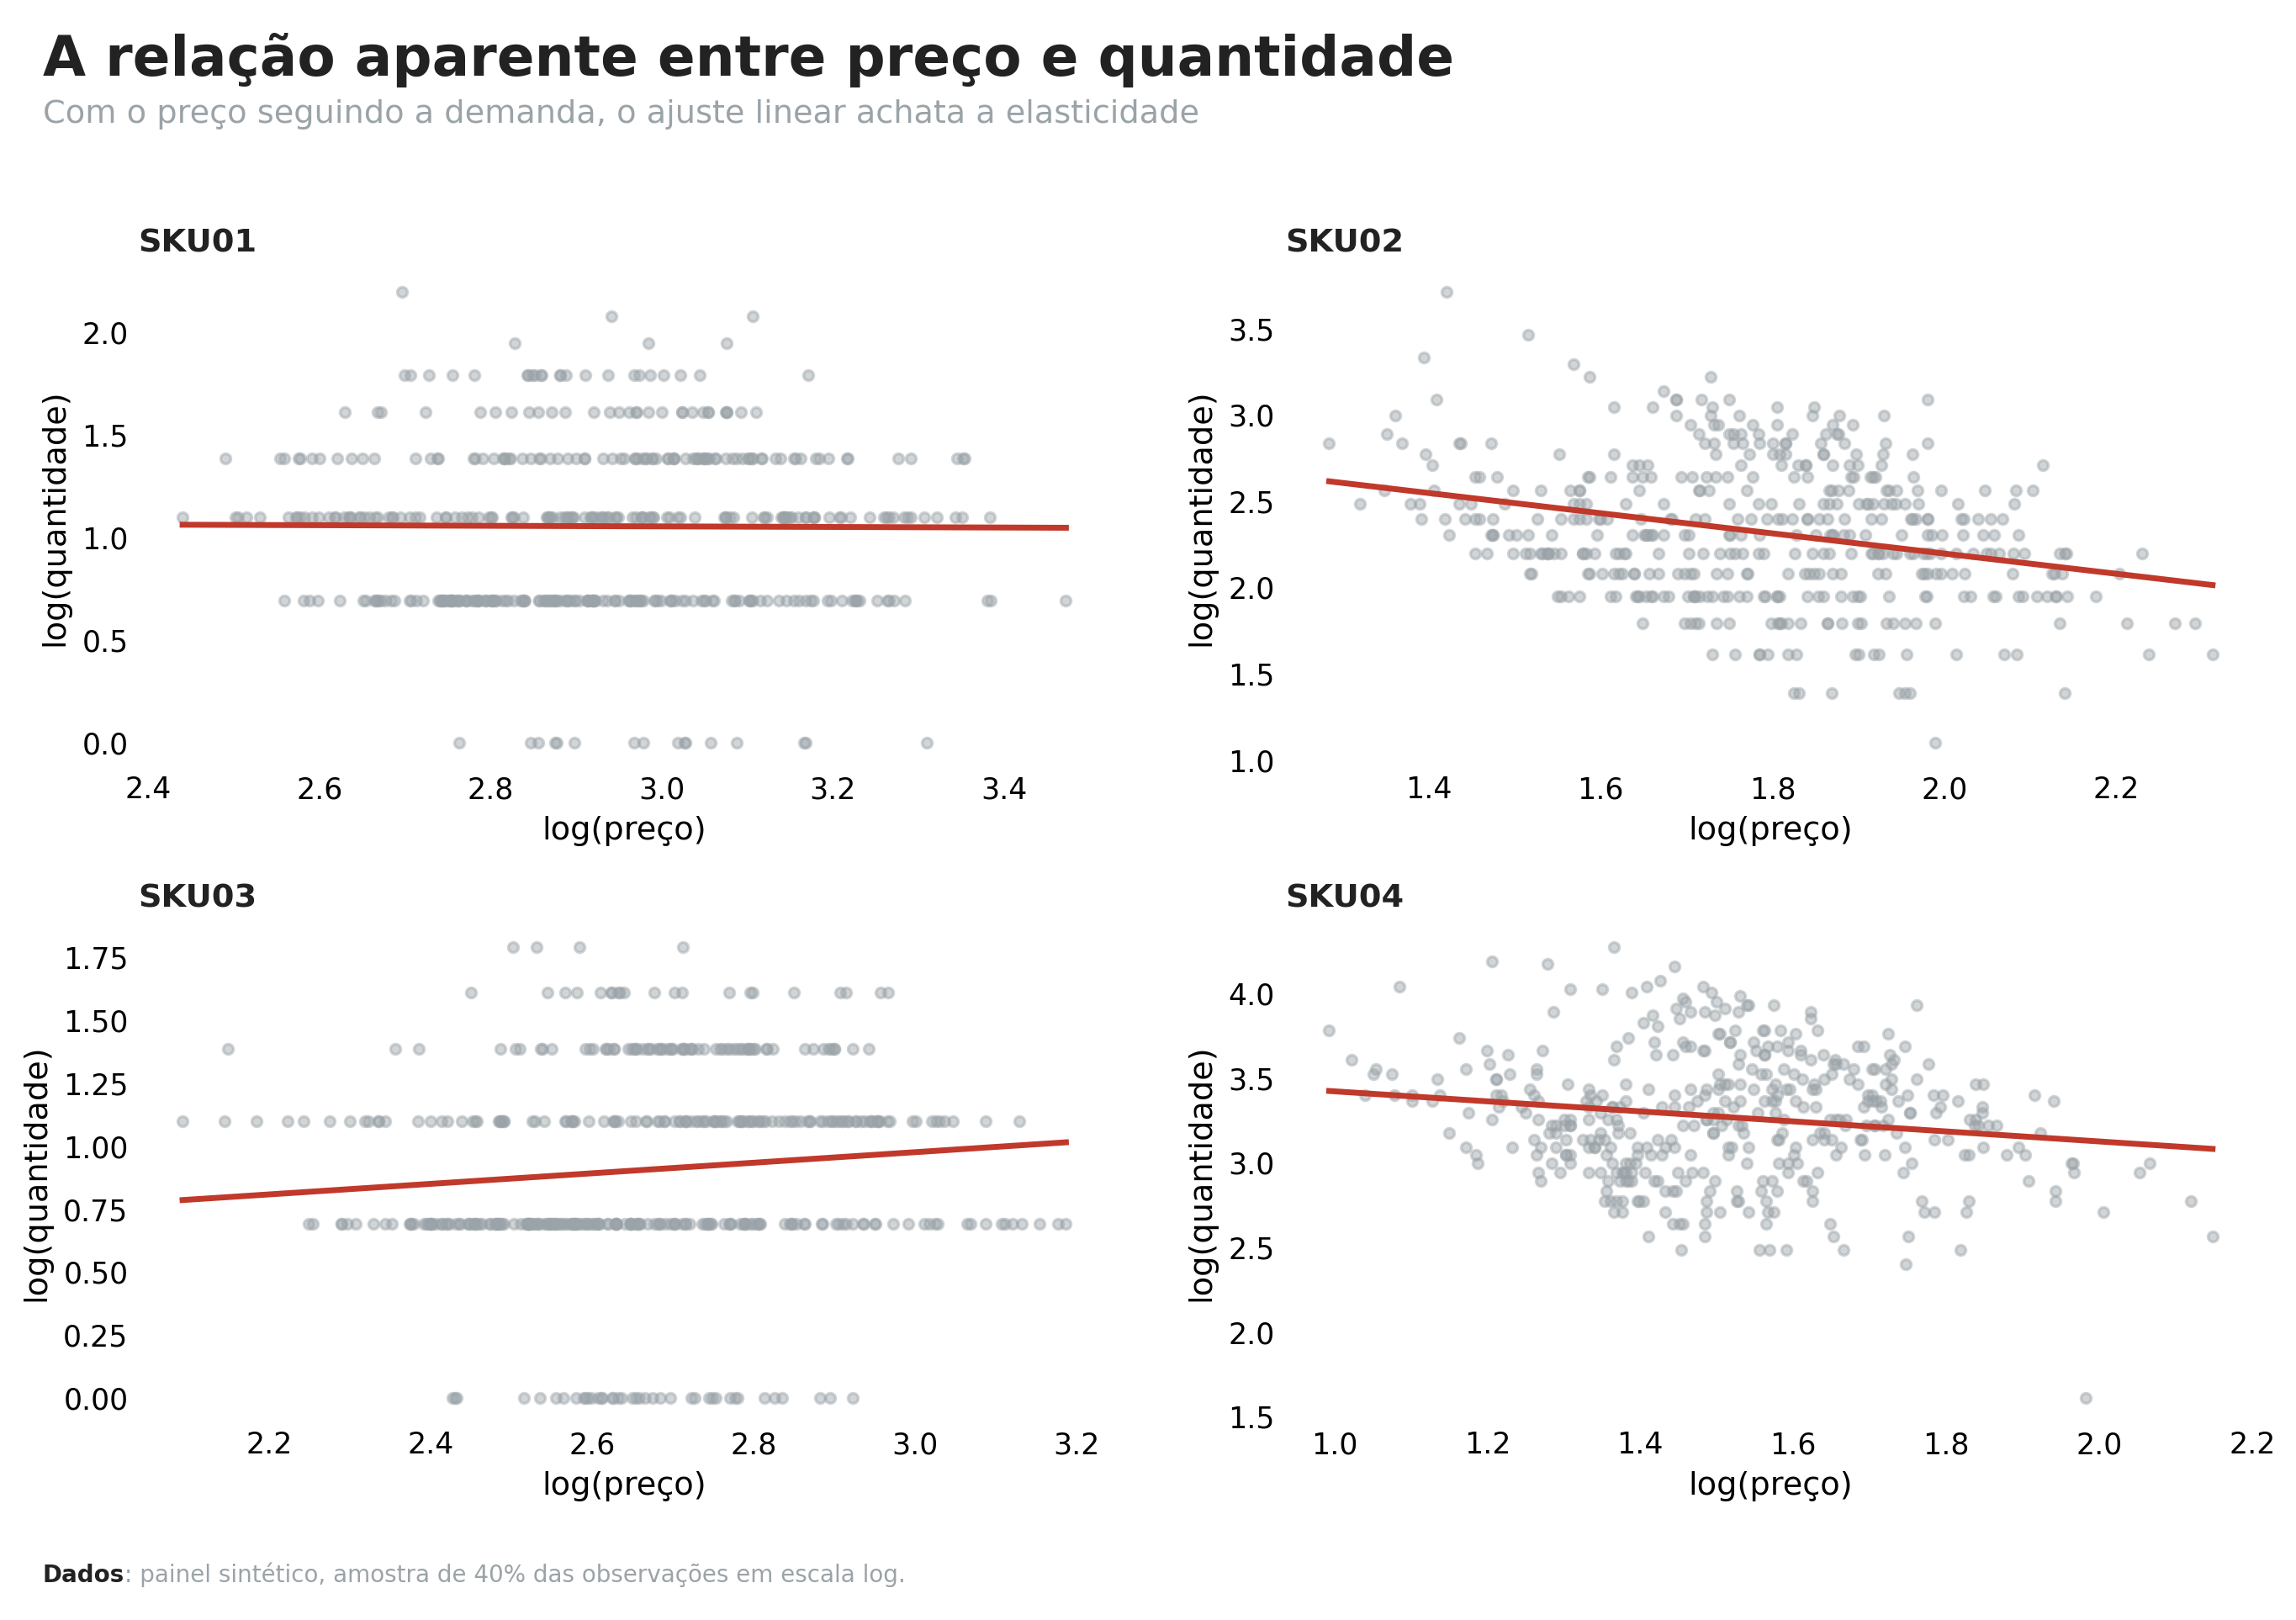

In [5]:
# fig 2: relação aparente entre preço e quantidade em escala log (ajuste ingênuo)
amostra = df.sample(frac=0.4, random_state=seed)

fig, axes = plt.subplots(2, 2, figsize=(13, 7.5), sharex=False)
fig.subplots_adjust(top=0.84, hspace=0.32, wspace=0.18)

for ax, sku in zip(axes.flat, skus):
    sub = amostra.loc[amostra["sku"] == sku]
    sns.regplot(
        data=sub,
        x="log_preco",
        y="log_qtd",
        scatter_kws={"s": 12, "color": cinza, "alpha": 0.45},
        line_kws={"color": vermelho, "linewidth": 2},
        ci=None,
        ax=ax,
    )
    limpar(ax)
    ax.set_title(sku, loc="left", fontsize=11, fontweight="bold", color=preto)
    ax.set_xlabel("log(preço)")
    ax.set_ylabel("log(quantidade)")

titulo(
    fig,
    "A relação aparente entre preço e quantidade",
    "Com o preço seguindo a demanda, o ajuste linear achata a elasticidade",
    y=0.99,
)
fonte(
    fig,
    "<Dados>: painel sintético, amostra de 40% das observações em escala log.",
    y=0.02,
)
plt.show()

## **Modelagem da Elasticidade**

O diagrama abaixo resume a estrutura causal do processo gerador: A demanda latente $X$ é uma causa comum da demanda e do preço. 

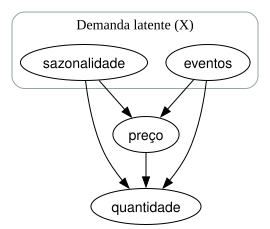

In [6]:
# fig 3: DAG causal sob precificação dinâmica
import graphviz as gr

dag = gr.Digraph()
dag.attr("node", shape="ellipse", fontname="Helvetica")
dag.attr("edge", fontname="Helvetica")

with dag.subgraph(name="cluster_demanda") as c:
    c.attr(label="Demanda latente (X)", color=cinza, style="rounded")
    c.node("X1", "sazonalidade")
    c.node("X2", "eventos")

dag.node("P", "preço")
dag.node("Q", "quantidade")
dag.edge("X1", "P")
dag.edge("X2", "P")
dag.edge("X1", "Q")
dag.edge("X2", "Q")
dag.edge("P", "Q")

dag

Para cada SKU comparamos dois modelos.

A regressão OLS _log-log_, modelo com ampla utilização em muitas empresas e que servirá como _baseline_. O modelo regride $\log Q$ sobre $\log P$. 

O outro é o **Double Machine Learning**, que estima um modelo parcialmente linear:

$$
\log Q = \theta \, \log P + g(X) + \zeta, \qquad \log P = m(X) + v
$$

As funções $g(X)$ e $m(X)$, a parte mais previsível da demanda e do preço a partir dos controles sazonais são aprendidas por modelos não lineares de machine learning como *random forests*. O DML então estima $\theta$ usando os resíduos das duas regressões. Em resumo, ele mede a elasticidade apenas na variação de preço que não é possível ser explicada pela demanda latente.

In [7]:
def estimar_elasticidade(dados, controles, learner):
    """Elasticidade por OLS log-log e por DML."""
    ols_fit = sm.OLS(dados["log_qtd"], sm.add_constant(dados[["log_preco"]])).fit(
        cov_type="HC3"
    )
    ols_ci = ols_fit.conf_int(alpha=0.05).loc["log_preco"]

    dml_data = DoubleMLData(dados, y_col="log_qtd", d_cols="log_preco", x_cols=controles)
    dml = DoubleMLPLR(dml_data, ml_l=clone(learner), ml_m=clone(learner), n_folds=5)
    dml.fit()
    ic = dml.confint(level=0.95)
    return {
        "ols": float(ols_fit.params["log_preco"]),
        "ols_se": float(ols_fit.bse["log_preco"]),
        "ols_inf": float(ols_ci[0]),
        "ols_sup": float(ols_ci[1]),
        "dml": float(dml.coef[0]),
        "dml_se": float(dml.se[0]),
        "dml_inf": float(ic.iloc[0, 0]),
        "dml_sup": float(ic.iloc[0, 1]),
    }

In [8]:
controles = ["demanda_latente", "sazonal", "feriado", "fim_de_semana"]

learner = RandomForestRegressor(
    n_estimators=300,
    max_depth=7,
    min_samples_leaf=6,
    max_features=0.8,
    random_state=seed,
    n_jobs=-1,
)

resultados = []
for sku, params in skus.items():
    dados = df.loc[df["sku"] == sku].reset_index(drop=True)
    r = estimar_elasticidade(dados, controles, learner)
    r["sku"] = sku
    r["verdadeira"] = params["elasticidade"]
    resultados.append(r)

resultados = pd.DataFrame(resultados)
resultados["erro_ols"] = (resultados["ols"] - resultados["verdadeira"]).abs()
resultados["erro_dml"] = (resultados["dml"] - resultados["verdadeira"]).abs()

resultados.round(3)

,ols,ols_se,ols_inf,ols_sup,dml,dml_se,dml_inf,dml_sup,sku,verdadeira,erro_ols,erro_dml
0,0.033,0.056,-0.076,0.143,-1.550,0.037,-1.622,-1.479,SKU01,-1.500,1.533,0.050
1,-0.615,0.050,-0.712,-0.518,-2.215,0.026,-2.267,-2.163,SKU02,-2.200,1.585,0.015
2,0.057,0.055,-0.050,0.164,-1.627,0.040,-1.706,-1.549,SKU03,-1.600,1.657,0.027
3,-0.225,0.050,-0.323,-0.128,-1.775,0.023,-1.820,-1.729,SKU04,-1.800,1.575,0.025


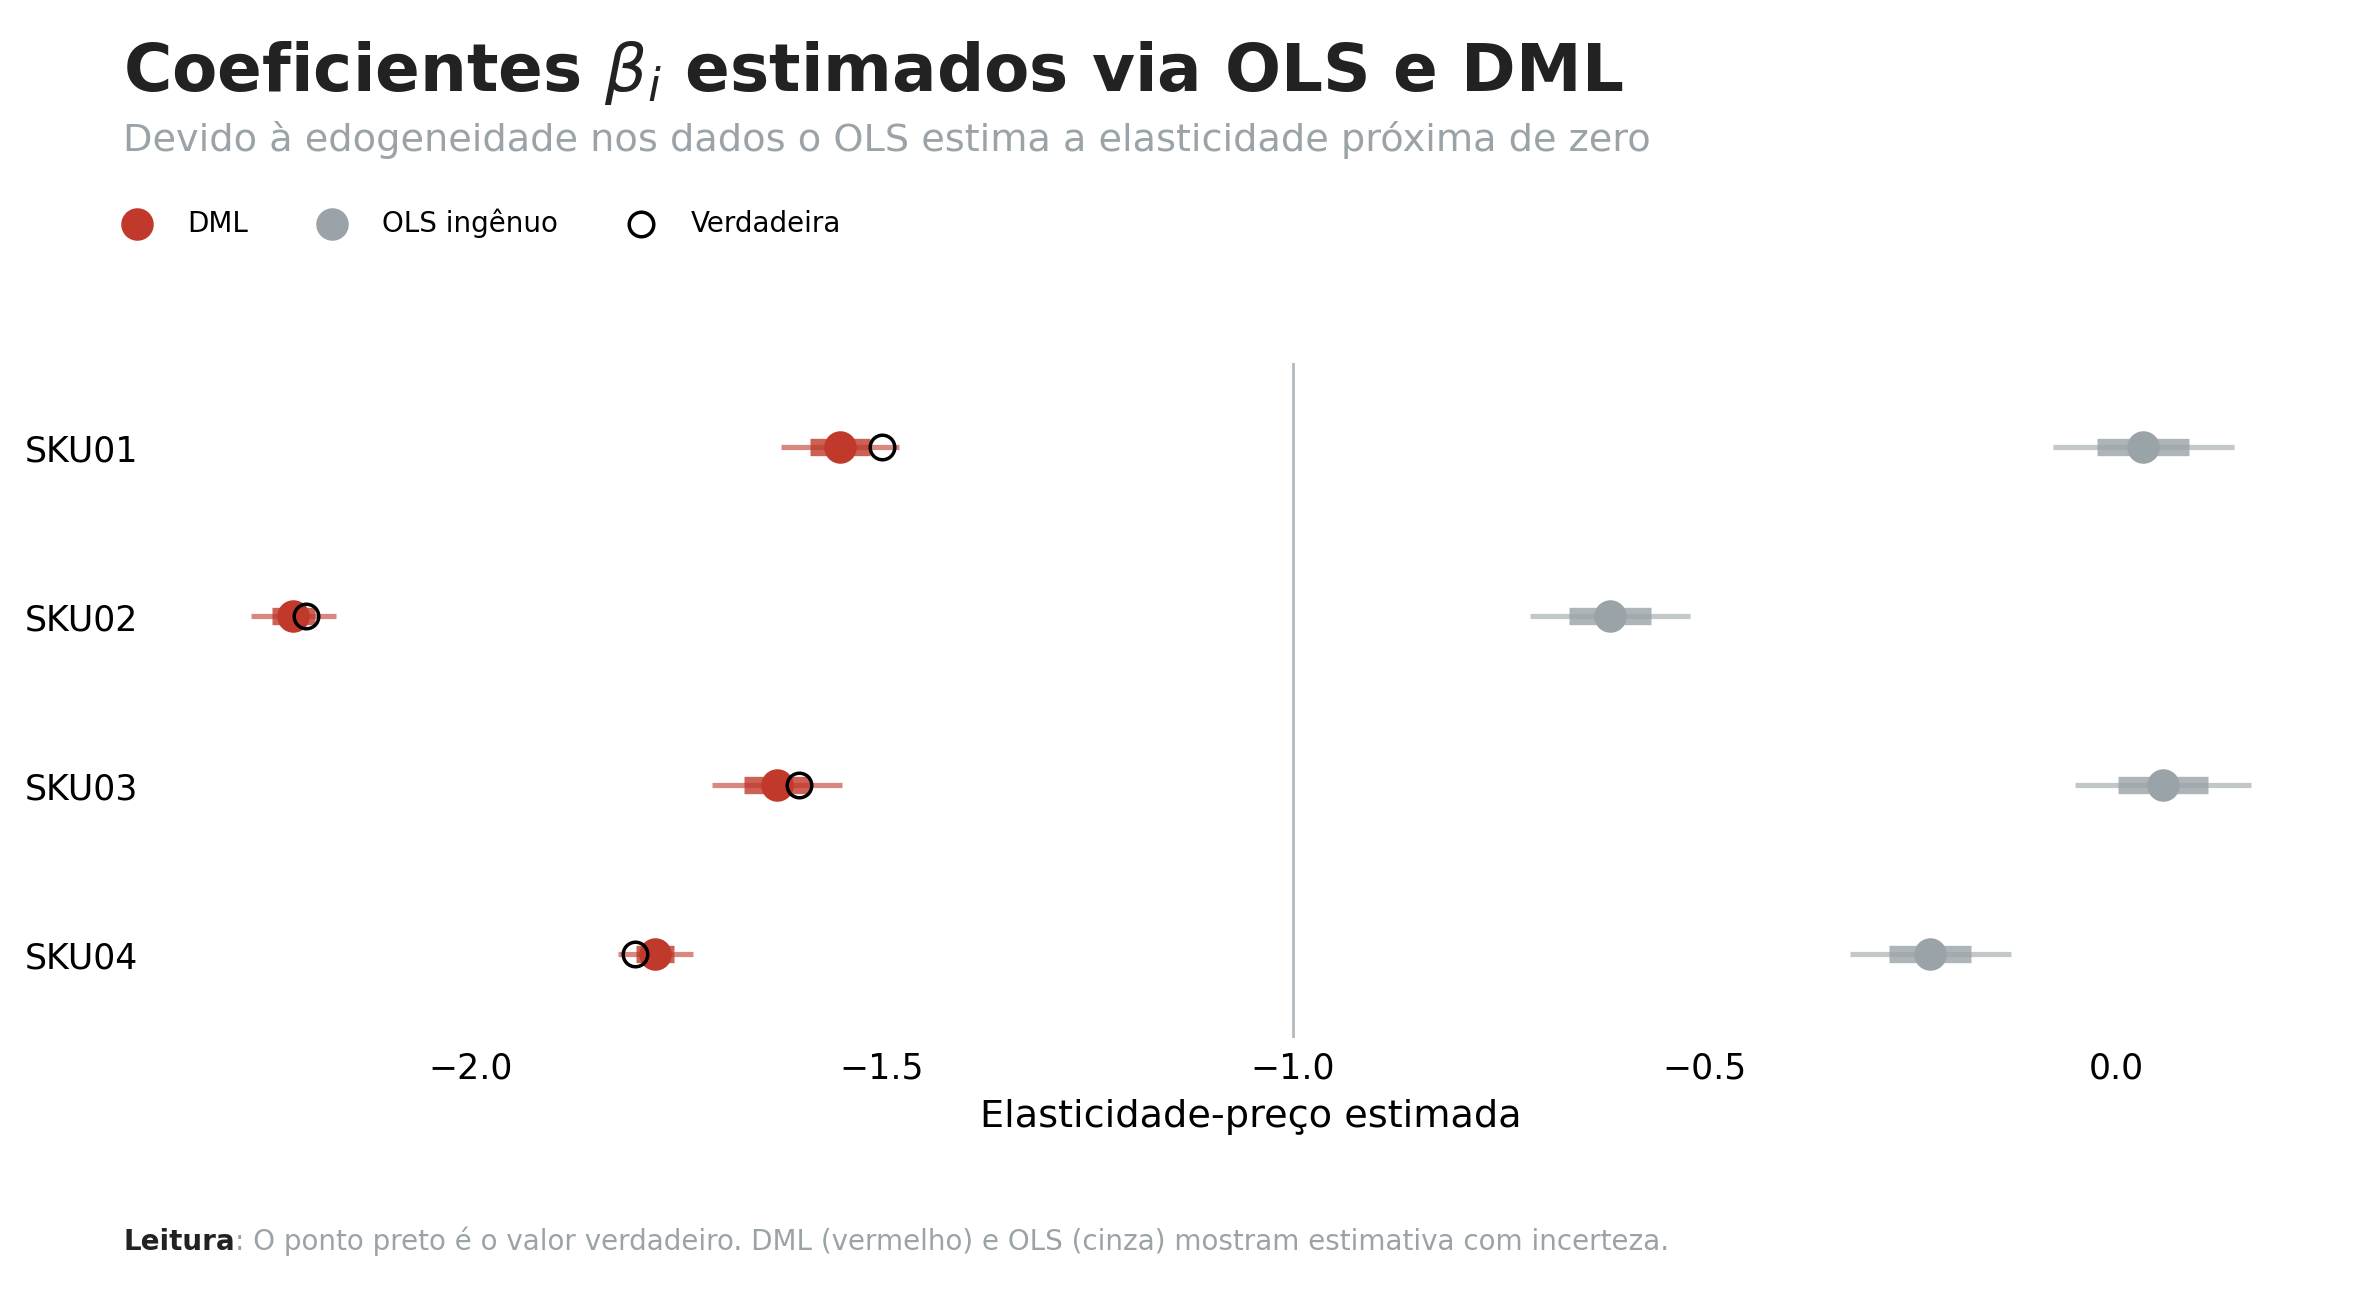

In [9]:
# fig 4: elasticidade verdadeira vs OLS ingênuo vs DML (com intervalos para ambos)
plot_df = resultados.sort_values("sku", ascending=False).reset_index(drop=True)
y = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(11, 5))
fig.subplots_adjust(top=0.72, bottom=0.18, left=0.10)

se_dml = (plot_df["dml_sup"] - plot_df["dml"]) / 1.96
se_ols = (plot_df["ols_sup"] - plot_df["ols"]) / 1.96

ax.hlines(
    y,
    plot_df["dml_inf"],
    plot_df["dml_sup"],
    color=vermelho,
    linewidth=1.5,
    alpha=0.6,
)
ax.hlines(
    y,
    plot_df["dml"] - se_dml,
    plot_df["dml"] + se_dml,
    color=vermelho,
    linewidth=5,
    alpha=0.8,
)

ax.hlines(
    y, plot_df["ols_inf"], plot_df["ols_sup"], color=cinza, linewidth=1.5, alpha=0.6
)
ax.hlines(
    y,
    plot_df["ols"] - se_ols,
    plot_df["ols"] + se_ols,
    color=cinza,
    linewidth=5,
    alpha=0.8,
)

ax.scatter(plot_df["dml"], y, color=vermelho, s=70, zorder=5, label="DML")
ax.scatter(plot_df["ols"], y, color=cinza, s=70, zorder=4, label="OLS ingênuo")
ax.scatter(
    plot_df["verdadeira"],
    y,
    color="#22222200",
    edgecolors="#000000FF",
    linewidths=1,
    s=50,
    marker="o",
    zorder=6,
    label="Verdadeira",
)

ax.axvline(-1, color=cinza, linestyle="-", linewidth=0.8, alpha=0.75)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["sku"])
ax.set_ylim(-0.5, len(plot_df) - 0.5)
ax.set_xlabel("Elasticidade-preço estimada")
limpar(ax)
ax.legend(
    frameon=False, ncol=3, loc="lower left", bbox_to_anchor=(-0.03, 1.15), fontsize=8
)

titulo(
    fig,
    r"Coeficientes $\beta_{i}$ estimados via OLS e DML",
    "Devido à edogeneidade nos dados o OLS estima a elasticidade próxima de zero",
)
fonte(
    fig,
    "<Leitura>: O ponto preto é o valor verdadeiro. DML (vermelho) e OLS (cinza) mostram estimativa com incerteza.",
)
plt.show()

É esperado, com base na teoria microeconômica, que a relação preço-demanda seja negativa. No entanto, o modelo _log-log_ estima, para dois SKUs, valores de coeficiente acima de 0. Esse resultado se deve à endogeneidade proposital simulada nos dados, caracterizada pela sazonalidade, eventos e períodos de alta estação, que são correlacionados ao mesmo tempo com o preço e com a demanda.

O modelo **DML** consegue isolar esse efeito e estimar corretamente a elasticidade, tendo todos os SKUs com a elasticidade verdadeira contida dentro do intervalo estimado.

## **Aplicações em Precificação**

Com a elasticidade estimada pelo DML é possível projetar como a demanda e lucro respondem às mudanças de preço. Partindo do preço e da demanda médios dos últimos 90 dias, a quantidade prevista a um multiplicador de preço $m$ é $Q(m) = Q_0 \, m^{\hat\theta}$, e o intervalo de confiança do DML se propaga diretamente para a curva.

Para o lucro, foi adotado um custo unitário é 45% do preço-base (margem bruta de 55%). Foram comparadas as duas decisões: o preço que maximiza o lucro segundo o DML e o preço que seria escolhido com OLS.

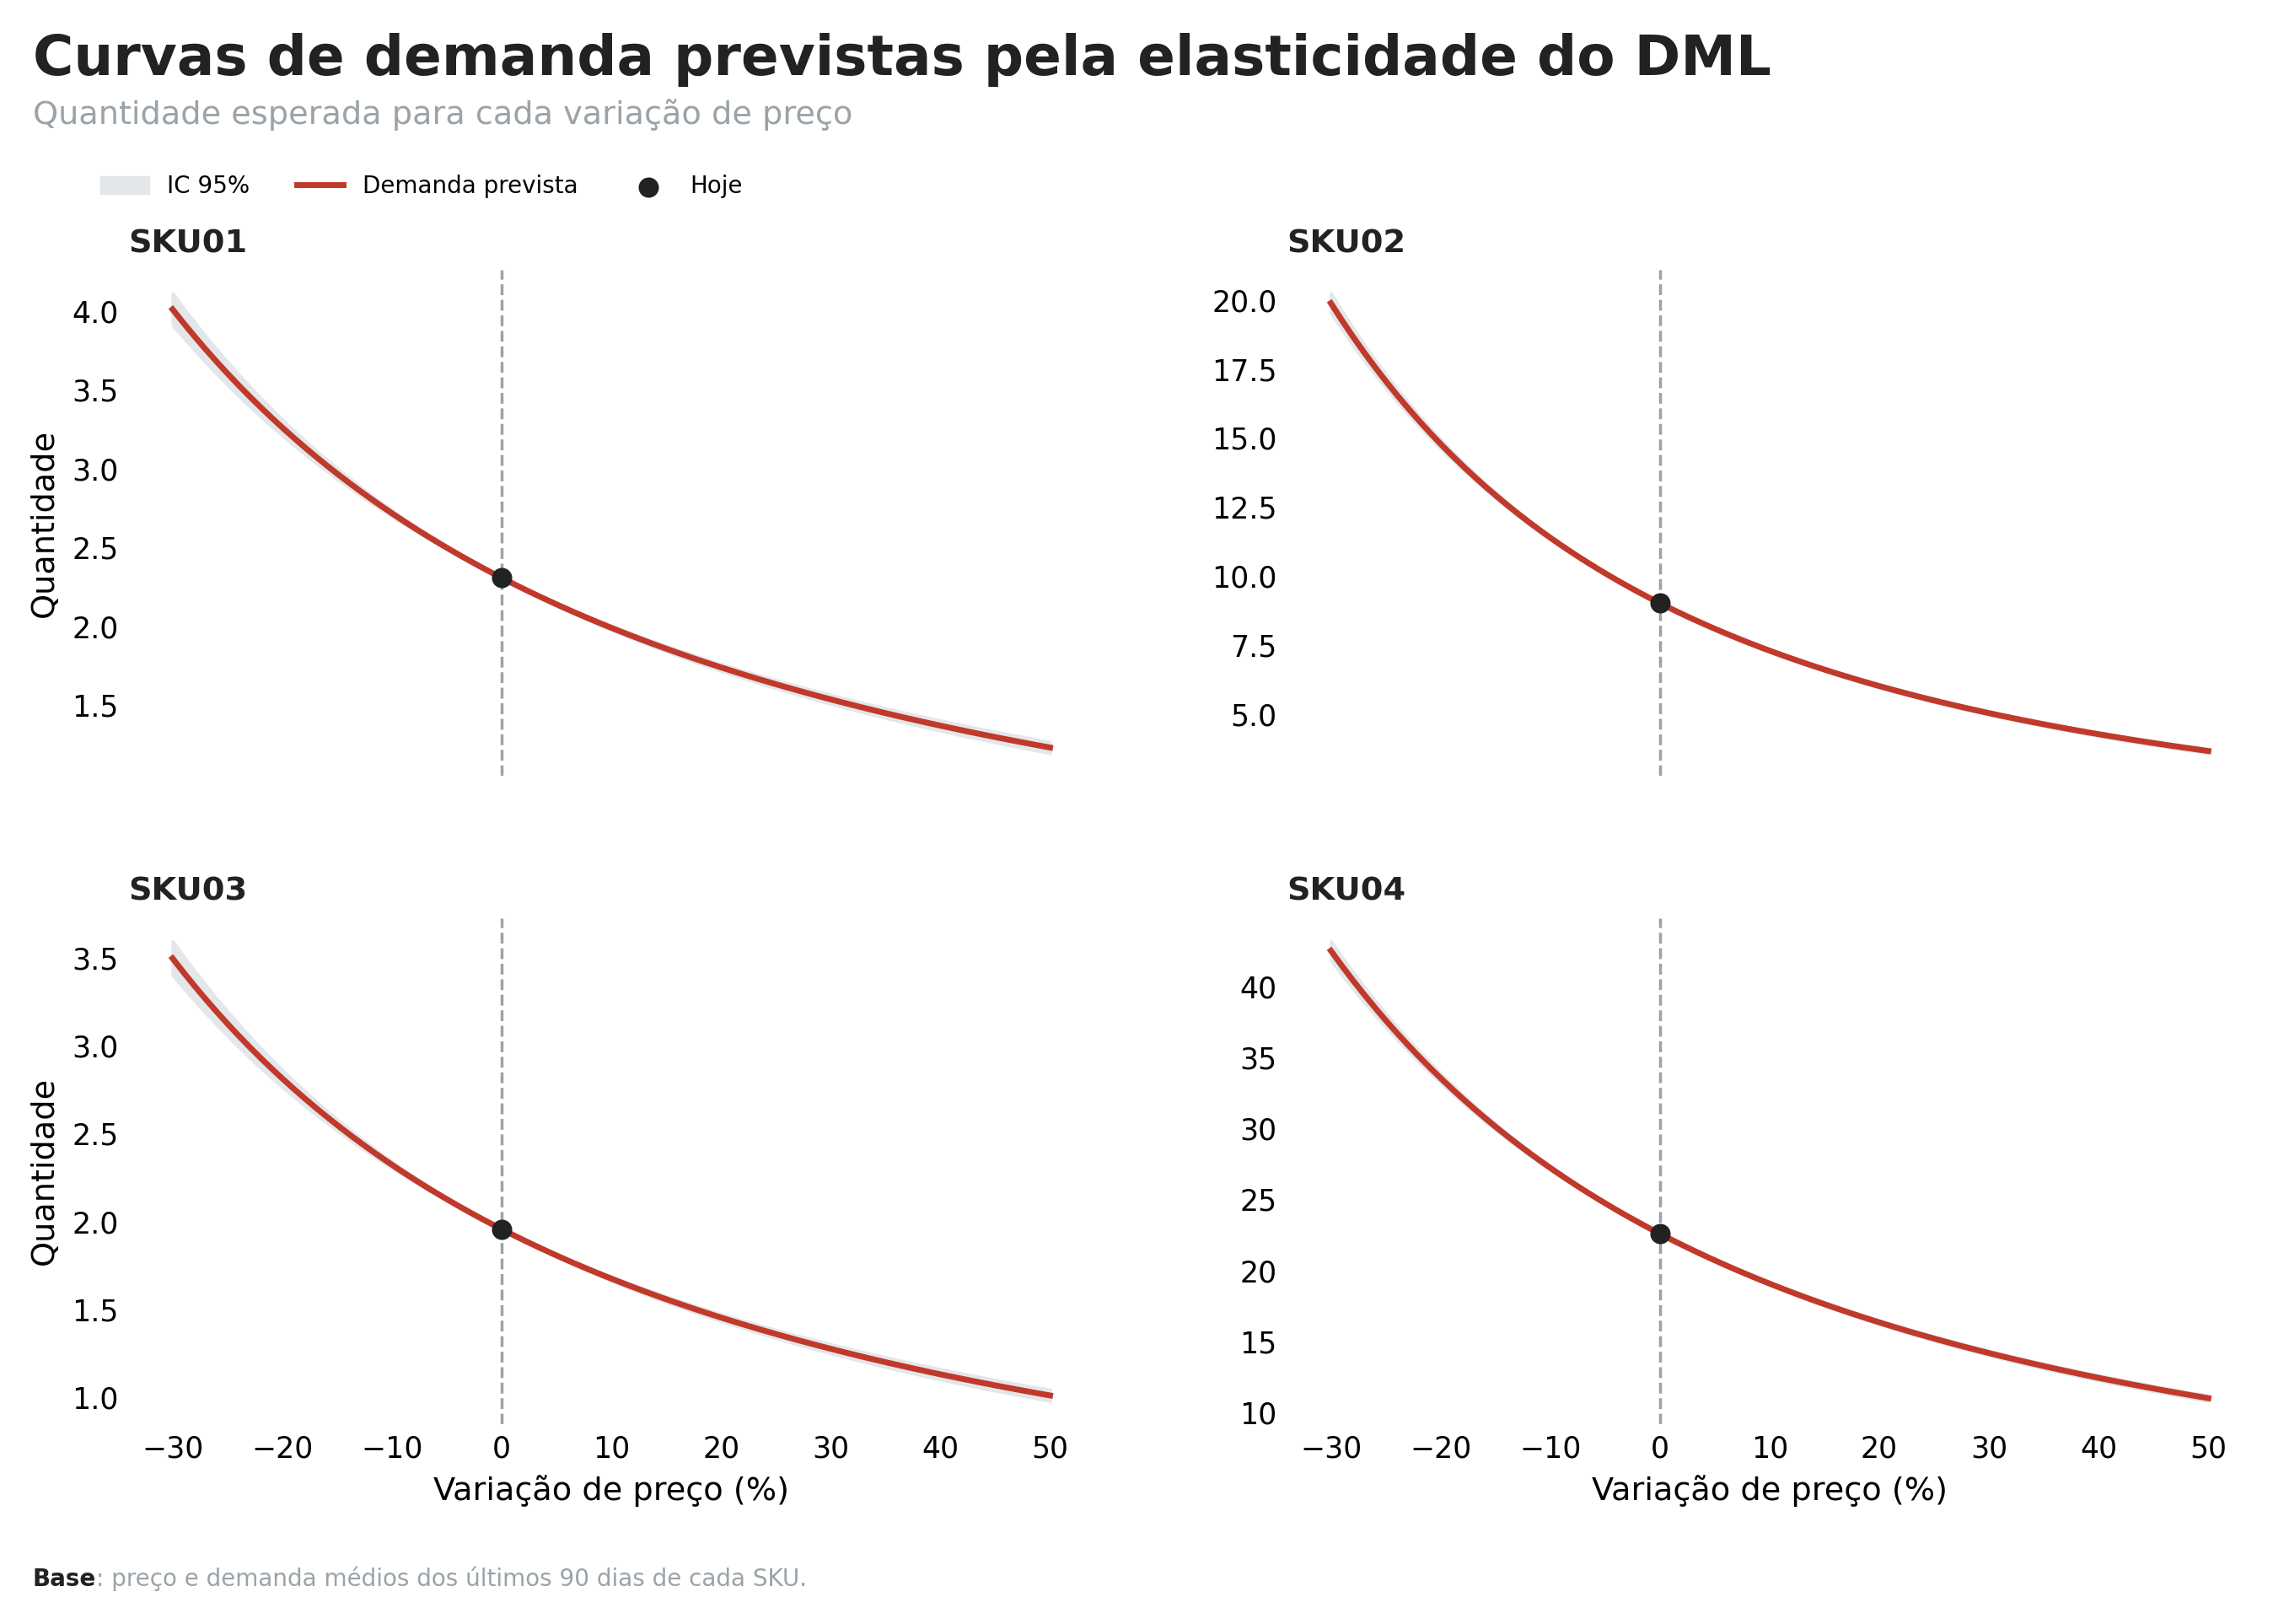

In [10]:
# base: preço e demanda médios dos últimos 90 dias
corte = df["data"].max() - pd.Timedelta(days=90)
base = (
    df.loc[df["data"] >= corte]
    .groupby("sku")
    .agg(preco_base=("preco", "mean"), qtd_base=("quantidade", "mean"))
    .reset_index()
    .merge(resultados, on="sku")
)

mult = np.linspace(0.70, 1.50, 80)
delta = (mult - 1) * 100

# fig 5: curvas de demanda previstas com intervalo de confiança do DML
fig, axes = plt.subplots(2, 2, figsize=(13, 7.5), sharex=True)
fig.subplots_adjust(top=0.84, hspace=0.28, wspace=0.20)

for ax, (_, r) in zip(axes.flat, base.iterrows()):
    q = r["qtd_base"] * mult ** r["dml"]
    q_inf = r["qtd_base"] * mult ** r["dml_sup"]
    q_sup = r["qtd_base"] * mult ** r["dml_inf"]
    ax.fill_between(delta, q_inf, q_sup, color=cinza_claro, label="IC 95%")
    ax.plot(delta, q, color=vermelho, linewidth=2, label="Demanda prevista")
    ax.scatter([0], [r["qtd_base"]], color=preto, s=35, zorder=5, label="Hoje")
    ax.axvline(0, color=cinza, linestyle="--", linewidth=1)
    limpar(ax)
    ax.set_title(r["sku"], loc="left", fontsize=11, fontweight="bold", color=preto)
    if _ % 2 == 0:
        ax.set_ylabel(f"Quantidade")
    if _ >= 2:
        ax.set_xlabel("Variação de preço (%)")


axes.flat[0].legend(
    frameon=False, ncol=3, loc="lower left", bbox_to_anchor=(-0.050, 1.10), fontsize=8
)
titulo(
    fig,
    "Curvas de demanda previstas pela elasticidade do DML",
    "Quantidade esperada para cada variação de preço",
    y=0.99,
)
fonte(fig, "<Base>: preço e demanda médios dos últimos 90 dias de cada SKU.", y=0.02)
plt.show()

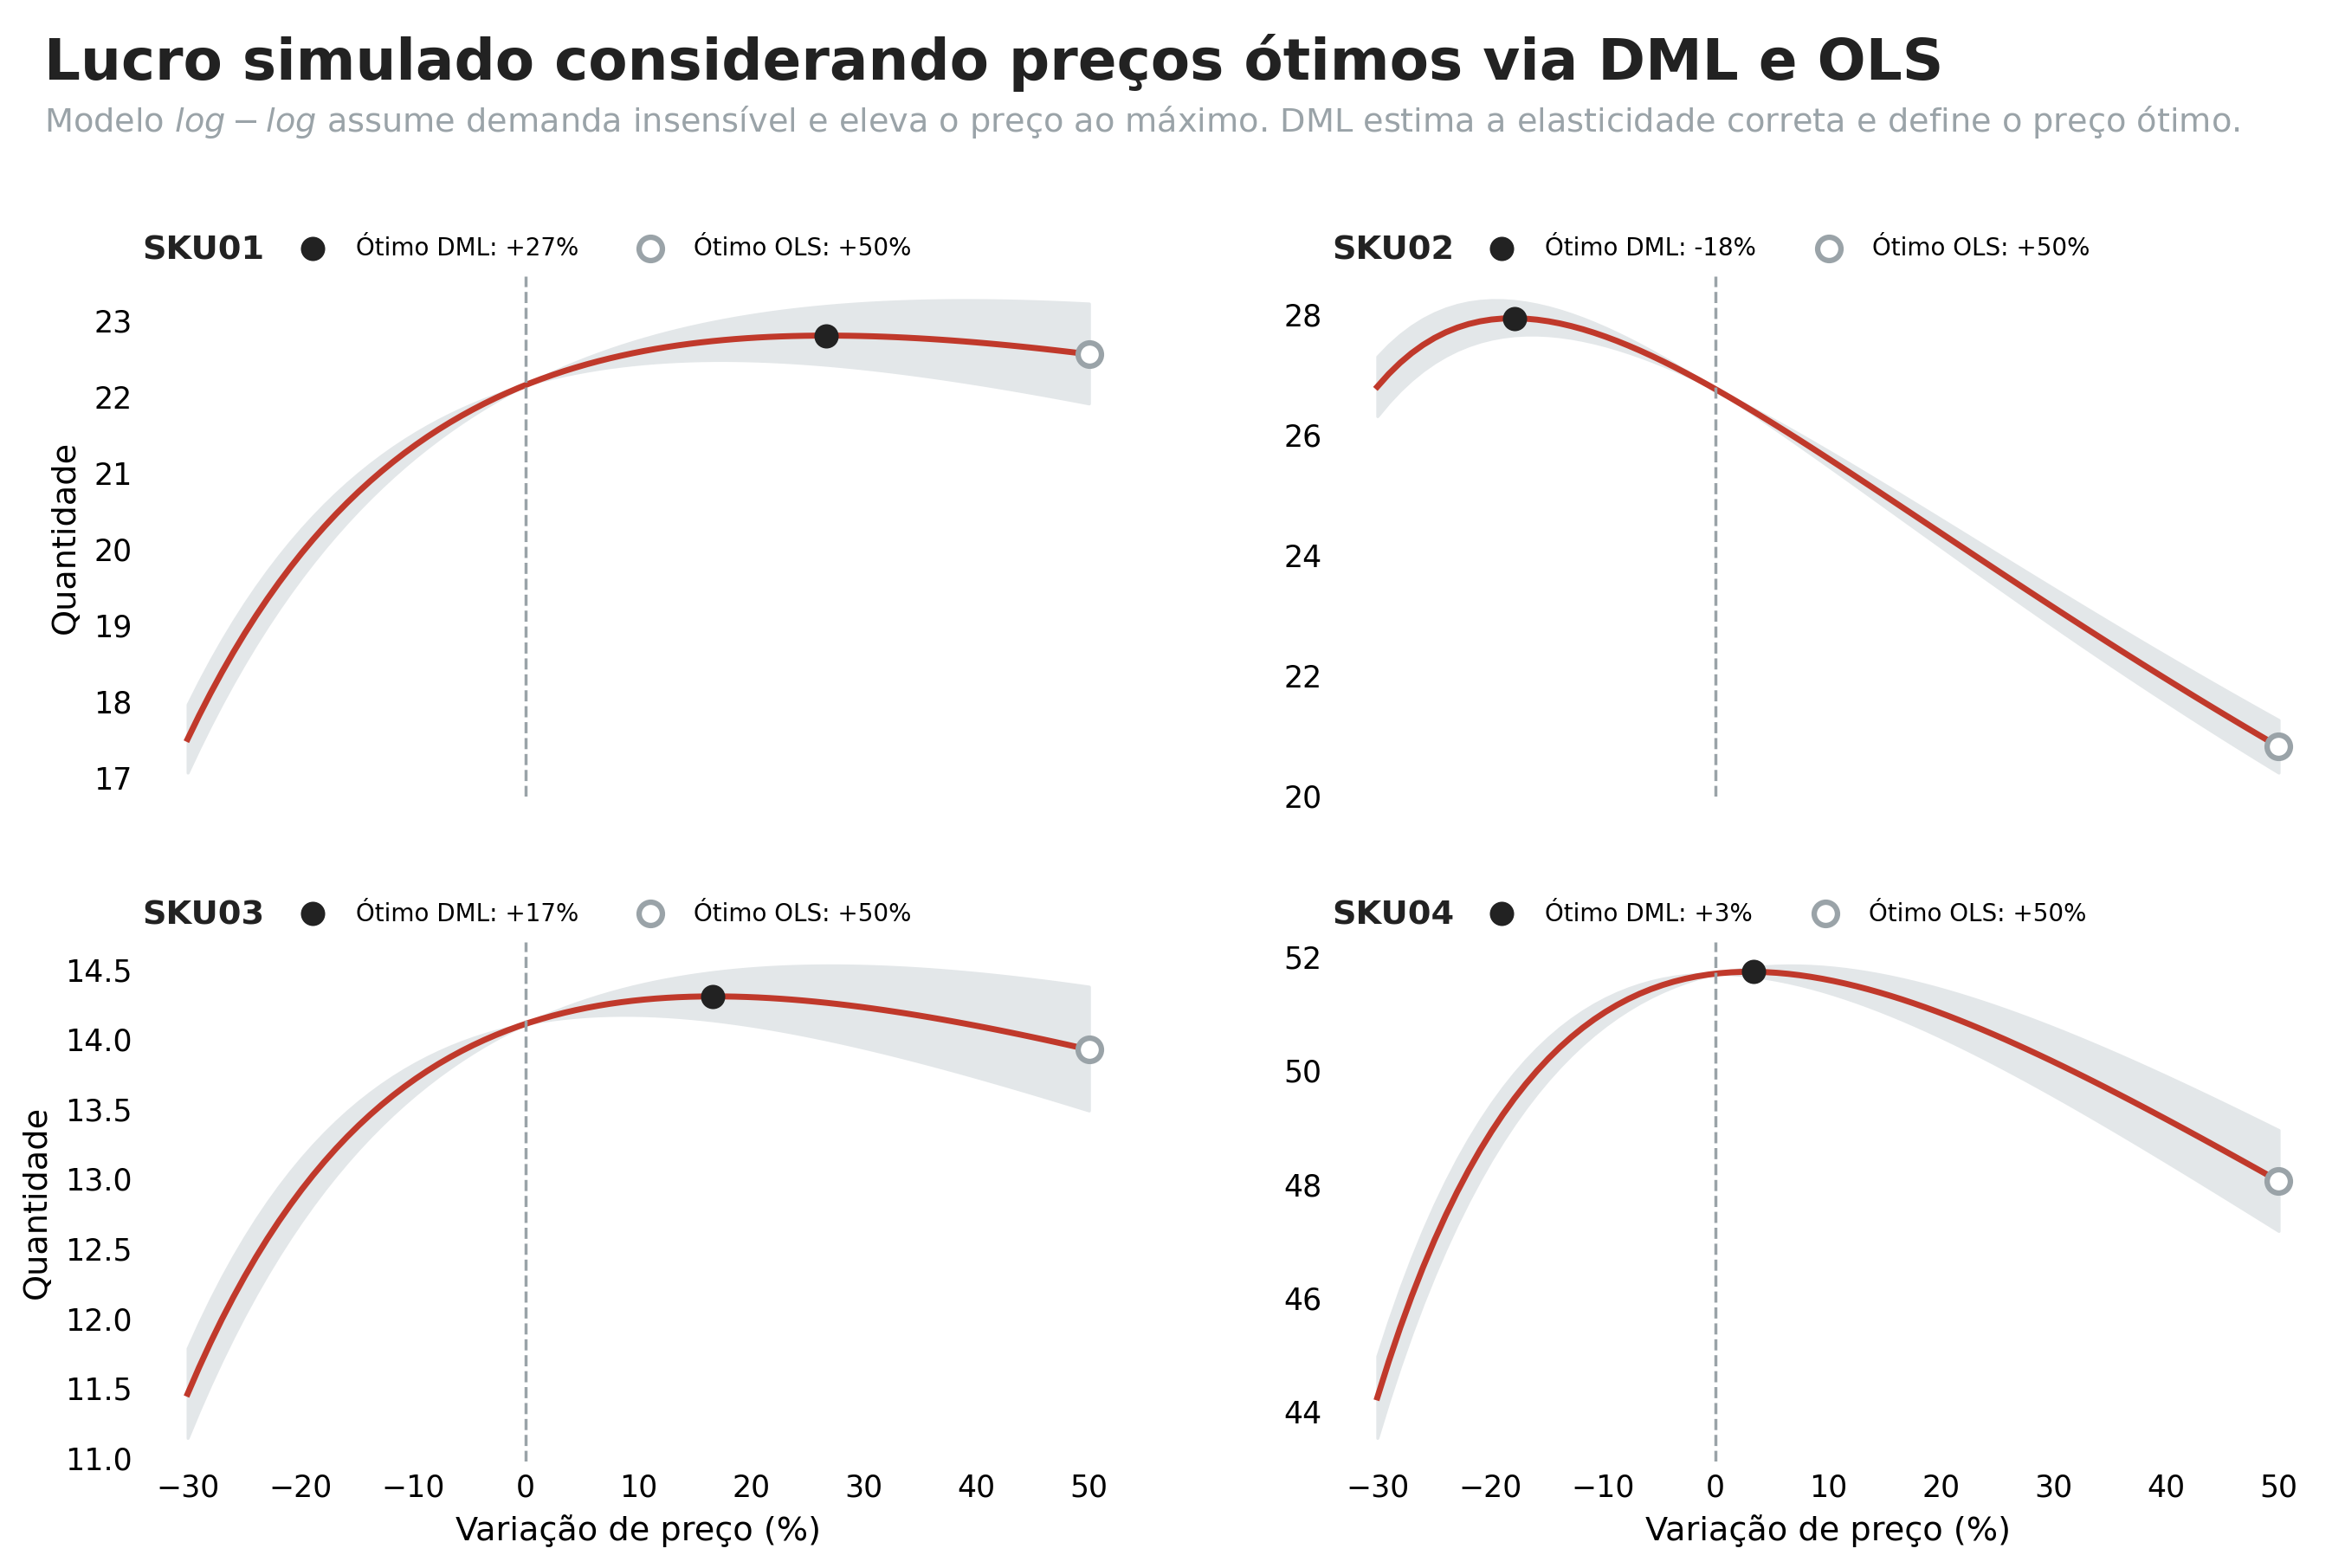

In [11]:
# fig 6: lucro estimado usando DML vs OLS
custo_frac = 0.45
linhas = []

fig, axes = plt.subplots(2, 2, figsize=(13, 7.5), sharex=True)
fig.subplots_adjust(top=0.84, hspace=0.28, wspace=0.20)

for ax, (_, r) in zip(axes.flat, base.iterrows()):
    custo = custo_frac * r["preco_base"]
    margem = r["preco_base"] * mult - custo
    lucro = margem * (r["qtd_base"] * mult ** r["dml"])
    lucro_inf = margem * (r["qtd_base"] * mult ** r["dml_sup"])
    lucro_sup = margem * (r["qtd_base"] * mult ** r["dml_inf"])
    lucro_ols = margem * (r["qtd_base"] * mult ** r["ols"])

    i_dml = int(np.argmax(lucro))
    i_ols = int(np.argmax(lucro_ols))
    perda = 100 * (lucro[i_dml] - lucro[i_ols]) / lucro[i_dml]
    linhas.append(
        {
            "sku": r["sku"],
            "verdadeira": r["verdadeira"],
            "ols": r["ols"],
            "dml": r["dml"],
            "preco_otimo_dml": delta[i_dml],
            "preco_pelo_ols": delta[i_ols],
            "lucro_perdido_pct": perda,
        }
    )

    ax.fill_between(delta, lucro_inf, lucro_sup, color=cinza_claro)
    ax.plot(delta, lucro, color=vermelho, linewidth=2)
    ax.scatter(
        [delta[i_dml]],
        [lucro[i_dml]],
        color=preto,
        s=50,
        zorder=6,
        label=f"Ótimo DML: {delta[i_dml]:+.0f}%",
    )
    ax.scatter(
        [delta[i_ols]],
        [lucro[i_ols]],
        facecolors="white",
        edgecolors=cinza,
        linewidths=1.8,
        s=60,
        zorder=6,
        label=f"Ótimo OLS: {delta[i_ols]:+.0f}%",
    )
    ax.axvline(0, color=cinza, linestyle="--", linewidth=1)
    limpar(ax)
    ax.set_title(r["sku"], loc="left", fontsize=11, fontweight="bold", color=preto)
    if _ % 2 == 0:
        ax.set_ylabel(f"Quantidade")
    if _ >= 2:
        ax.set_xlabel("Variação de preço (%)")
    ax.legend(
        frameon=False,
        ncols=2,
        loc="lower left",
        bbox_to_anchor=(0.125, 0.99),
        fontsize=8,
    )

titulo(
    fig,
    "Lucro simulado considerando preços ótimos via DML e OLS",
    "Modelo $log-log$ assume demanda insensível e eleva o preço ao máximo. "
    "DML estima a elasticidade correta e define o preço ótimo.",
    y=0.99,
)
plt.show()

## **Conclusões**

- Sob contexto de preços dinâmico que acompanham a demanda, o **OLS** se distanciou da elasticidade base em todas as SKUs, justamente por confundir o efeito negativo do preço com o efeito positivo da demanda latente. O **DML** estimou a elasticidade corretamente dentro do intervalo de confiança em todos os casos, usando apenas a variação de preço não explicada pela demanda.
- A consequência prática de confiar no OLS é aumentar preços acreditando não perder volume, quando na verdade a demanda é elástica, o que resultará em perda de venda. A curva de lucro mostra o lucro perdido ao seguir essa recomendação.

## **Referências**

- [Chernozhukov, V. et al. (2018). *Double/Debiased Machine Learning for Treatment and Structural Parameters*. The Econometrics Journal, 21(1).](https://academic.oup.com/ectj/article/21/1/C1/5056401)
- [Zhang, B. et al. (2025). *A Debiased Machine Learning Framework for Optimizing Price Promotion within E-commerce*. KDD Applied Data Science Track.](https://causal-machine-learning.github.io/kdd2025-workshop/papers/24.pdf)
- [Orduz, J. C. (2023–2024). *Multilevel Elasticities for a Single SKU (Parts I–III)* e *Hierarchical Pricing Elasticity Models*.](https://juanitorduz.github.io/)
- [DoubleML. *Documentation*.](https://docs.doubleml.org/)
- [Vacanza. *Holidays*.](https://holidays.readthedocs.io/)